# Talk2Event — event visualization

Loads samples through the project's own `Talk2EventDataset` and visualizes the event
stream against the referring expression and ground-truth box.

**What the data looks like.** Each sample's `event` tensor is `(20, 480, 640)` of
*event counts*, already binned by the dataset authors. The 20 channels are
**polarity-major**: channel index `= p * T_FILE + t`, so channels 0–9 are polarity 0
(OFF / darkening) over 10 file bins, and channels 10–19 are polarity 1 (ON /
brightening) over the same bins.

**File bins vs. network steps.** The file stores `T_FILE = 10` bins, but the network
runs `T_STEPS = 5` simulation steps: each step sums two adjacent file bins. 5 divides
10 exactly, so every step spans an equal duration, counts stay integral, and no
interpolation is needed. Both quantities are declared in
`spiketrandvg.datasets.events_voxel_cube`, and `talk2event_cube()` applies them.

Boxes come out of the dataloader as **normalized `cxcywh` in [0, 1]**, so they must be
scaled by (640, 480) and converted to corners before drawing.

In [14]:
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.patches import Rectangle

from spiketrandvg.datasets.events_voxel_cube import (
    POLARITIES,
    T_FILE,
    T_STEPS,
    prebinned_to_voxel_cube,
    talk2event_cube,
    time_group_sizes,
)
from spiketrandvg.datasets.talk2event_dataset import CLASSES, Talk2EventDataset

H, W = 480, 640
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
IMAGENET_STD = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)

plt.rcParams["figure.dpi"] = 110
print("classes:", CLASSES)
print(f"T_FILE={T_FILE} file bins -> T_STEPS={T_STEPS} network steps "
      f"(grouping {time_group_sizes(T_FILE, T_STEPS)})")

ImportError: cannot import name 'POLARITIES' from 'spiketrandvg.datasets.events_voxel_cube' (/home/karthik/Desktop/PhD/talk2events_research/spiketrandvg/src/spiketrandvg/datasets/events_voxel_cube.py)

In [15]:
# ---- helpers -------------------------------------------------------------

def box_to_xyxy_px(box_cxcywh, w=W, h=H):
    """(4,) normalized cxcywh -> (x0, y0, x1, y1) in pixels."""
    cx, cy, bw, bh = [float(v) for v in box_cxcywh]
    return ((cx - bw / 2) * w, (cy - bh / 2) * h, (cx + bw / 2) * w, (cy + bh / 2) * h)


def draw_box(ax, box_cxcywh, color="lime", lw=2.0, label=None):
    x0, y0, x1, y1 = box_to_xyxy_px(box_cxcywh)
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                           fill=False, edgecolor=color, linewidth=lw))
    if label:
        ax.text(x0, max(y0 - 5, 8), label, color=color, fontsize=8,
                bbox=dict(facecolor="black", alpha=0.55, pad=1.5, edgecolor="none"))


def file_bins(event):
    """(20, H, W) -> (T_FILE, 2, H, W): the raw binning as stored on disk."""
    return prebinned_to_voxel_cube(event, T=T_FILE, polarities=POLARITIES)


def split_polarity(event):
    """(20, H, W) -> (off, on), each (T_FILE, H, W). Relies on ch = p*T_FILE + t."""
    cube = file_bins(event)
    return cube[:, 0], cube[:, 1]


def denorm_image(img):
    """Undo the dataset's ImageNet normalization -> (H, W, 3) in [0, 1]."""
    a = img.numpy() * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(a, 0, 1).transpose(1, 2, 0)


def wrap(text, width=88):
    words, lines, cur = text.split(), [], ""
    for wd in words:
        if len(cur) + len(wd) + 1 > width:
            lines.append(cur); cur = wd
        else:
            cur = f"{cur} {wd}".strip()
    if cur:
        lines.append(cur)
    return "\n".join(lines)


print("helpers ready")

helpers ready


In [16]:
SPLIT = "test"        # "train" or "test"
ds = Talk2EventDataset(SimpleNamespace(attribute="all"), image_set=SPLIT)
print(f"\n{SPLIT}: {len(ds)} samples")

Initializing Talk2EventDataset
missing 0 attributes
load 7665 data from test split
false match 0 attributes



test: 7665 samples


In [17]:
SAMPLE_IDX = 0    # <-- change me

inp, tgt = ds[SAMPLE_IDX]
event, box = inp["event"], tgt["boxes"][0]

print(f"sample {SAMPLE_IDX}  |  class: {tgt['category']}")
print(f"event tensor : {tuple(event.shape)} {event.dtype}  "
      f"counts 0..{int(event.max())}, {100 * (event != 0).float().mean():.2f}% non-zero")
print(f"total events : {int(event.sum()):,}")
print(f"box (cxcywh) : {[round(float(v), 4) for v in box]}")
print(f"box (px xyxy): {[round(v, 1) for v in box_to_xyxy_px(box)]}")
print(f"\ncaption:\n{wrap(tgt['caption'])}")

sample 0  |  class: car
event tensor : (20, 480, 640) torch.float32  counts 0..10, 10.21% non-zero
total events : 952,578
box (cxcywh) : [0.5156, 0.4719, 0.075, 0.0812]
box (px xyxy): [306.0, 207.0, 354.0, 246.0]

caption:
a dark-colored sedan is moving slowly on a winding road , positioned in the center of
the road slightly to the right , with trees and a rocky hillside on the left .. not
mentioned


## 1. Accumulated event frame

All 20 channels summed — every event in the sample collapsed onto one image. This is the
closest thing to "what the event camera saw". Bright regions are where the most change
happened, which is why moving objects and edges dominate.

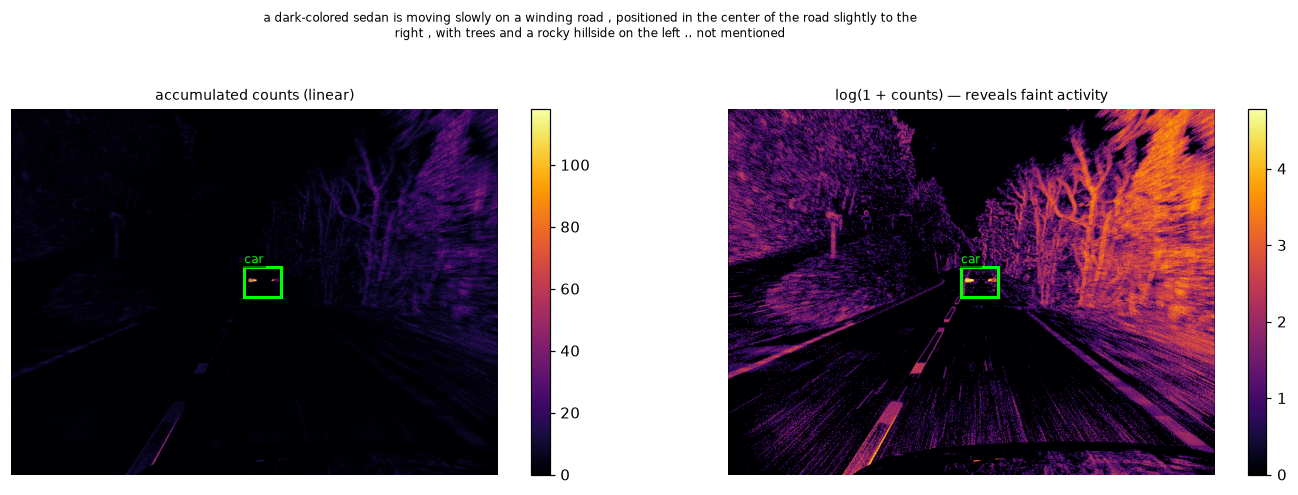

In [18]:
acc = event.sum(0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, (data, title) in zip(axes, [
    (acc, "accumulated counts (linear)"),
    (np.log1p(acc), "log(1 + counts) — reveals faint activity"),
]):
    im = ax.imshow(data, cmap="inferno")
    draw_box(ax, box, label=tgt["category"])
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.03)
fig.suptitle(wrap(tgt["caption"], 110), fontsize=8, y=1.04)
plt.tight_layout(); plt.show()

## 2. Polarity

ON events (brightening, polarity 1 = channels 10–19) against OFF events (darkening,
polarity 0 = channels 0–9). An object moving against a background typically produces ON
on its leading edge and OFF on its trailing edge, so the two are spatially offset.

In [19]:
off, on = split_polarity(event)
off_sum, on_sum = off.sum(0).numpy(), on.sum(0).numpy()

# red = ON, blue = OFF, normalized jointly so the two are comparable
scale = max(on_sum.max(), off_sum.max(), 1)
rgb = np.zeros((H, W, 3))
rgb[..., 0] = on_sum / scale
rgb[..., 2] = off_sum / scale

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for ax, (d, t, cm) in zip(axes, [
    (on_sum, f"ON / brightening  ({int(on_sum.sum()):,} events)", "Reds"),
    (off_sum, f"OFF / darkening  ({int(off_sum.sum()):,} events)", "Blues"),
    (rgb, "composite — red=ON, blue=OFF", None),
]):
    ax.imshow(d, cmap=cm)
    draw_box(ax, box, color="lime")
    ax.set_title(t, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

NameError: name 'T_FILE' is not defined

## 3. Temporal evolution — network steps

The `T_STEPS = 5` steps the spiking network actually consumes, produced by
`talk2event_cube()`. Each step is the sum of two adjacent file bins, so all steps span
an equal duration and event mass is spread evenly across them.

Motion shows up as activity drifting across the frame from step to step. A shared colour
scale is used so steps are directly comparable.

network input cube: (5, 2, 480, 640)  total events 952,578 (source 952,578)


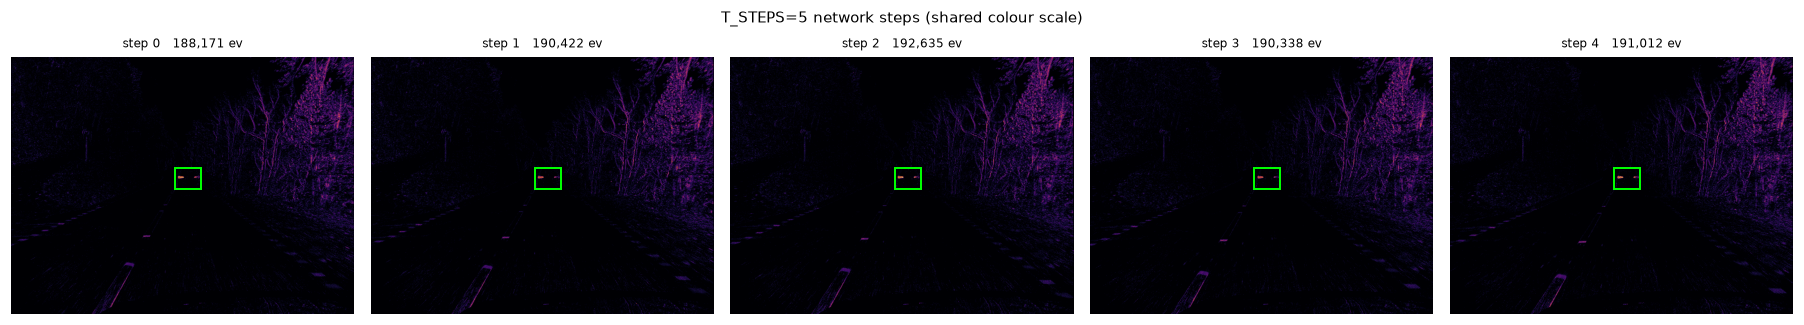

In [ ]:
cube = talk2event_cube(event)                 # (T_STEPS, 2, H, W) = (5, 2, 480, 640)
per_step = cube.sum(1).numpy()                # (5, H, W), both polarities
vmax = per_step.max()

print(f"network input cube: {tuple(cube.shape)}  "
      f"total events {int(cube.sum()):,} (source {int(event.sum()):,})")

fig, axes = plt.subplots(1, T_STEPS, figsize=(3.3 * T_STEPS, 3.0))
for s, ax in enumerate(np.atleast_1d(axes).ravel()):
    ax.imshow(per_step[s], cmap="inferno", vmin=0, vmax=vmax)
    draw_box(ax, box, color="lime", lw=1.3)
    ax.set_title(f"step {s}   {int(per_step[s].sum()):,} ev", fontsize=8)
    ax.axis("off")
fig.suptitle(f"T_STEPS={T_STEPS} network steps (shared colour scale)", fontsize=10)
plt.tight_layout(); plt.show()

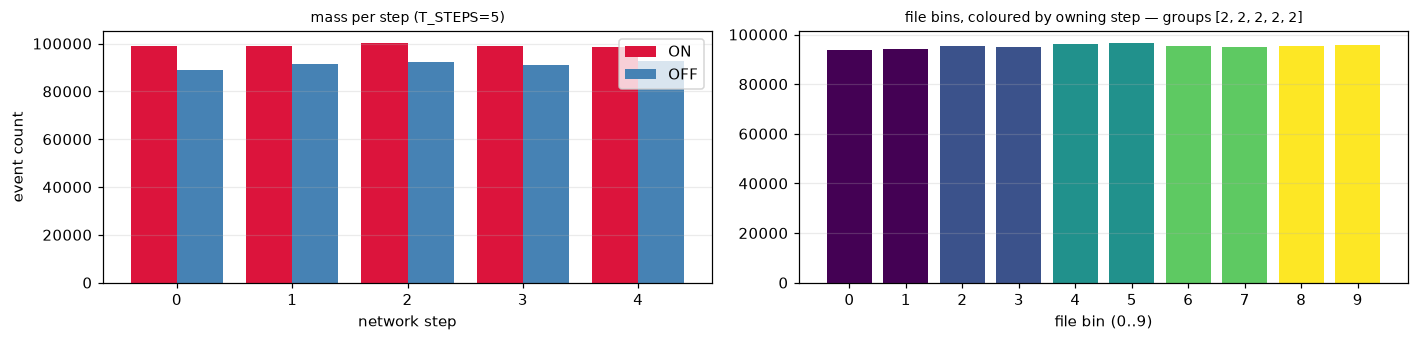

mass preserved exactly: 952,578 events
counts still integral:  True


In [ ]:
# event mass per network step, split by polarity
on_ps, off_ps = cube[:, 1].sum((1, 2)).numpy(), cube[:, 0].sum((1, 2)).numpy()
xs = np.arange(T_STEPS)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
axes[0].bar(xs - 0.2, on_ps, 0.4, label="ON", color="crimson")
axes[0].bar(xs + 0.2, off_ps, 0.4, label="OFF", color="steelblue")
axes[0].set_xlabel("network step"); axes[0].set_ylabel("event count"); axes[0].set_xticks(xs)
axes[0].set_title(f"mass per step (T_STEPS={T_STEPS})", fontsize=9)
axes[0].legend(); axes[0].grid(alpha=0.25, axis="y")

# the underlying 10 file bins, coloured by which step absorbs each pair
fb = file_bins(event).sum(1).sum((1, 2)).numpy()
sizes = time_group_sizes(T_FILE, T_STEPS)
owner = np.repeat(np.arange(T_STEPS), sizes)
axes[1].bar(np.arange(T_FILE), fb, color=plt.cm.viridis(owner / max(T_STEPS - 1, 1)))
axes[1].set_xlabel(f"file bin (0..{T_FILE - 1})"); axes[1].set_xticks(np.arange(T_FILE))
axes[1].set_title(f"file bins, coloured by owning step — groups {sizes}", fontsize=9)
axes[1].grid(alpha=0.25, axis="y")
plt.tight_layout(); plt.show()

assert int(cube.sum()) == int(event.sum()), "rebinning must preserve event mass"
print(f"mass preserved exactly: {int(cube.sum()):,} events")
print(f"counts still integral:  {bool(torch.equal(cube, cube.round()))}")

## 4. Events vs. the RGB frame

The aligned grayscale/RGB frame for reference. Useful for sanity-checking that the box
and caption really describe the object the events light up.

> The dataloader builds `image_path` by replacing `.jpg` with `.png`. If the frames are
> not present on disk this cell reports that and skips — the event pipeline is unaffected.

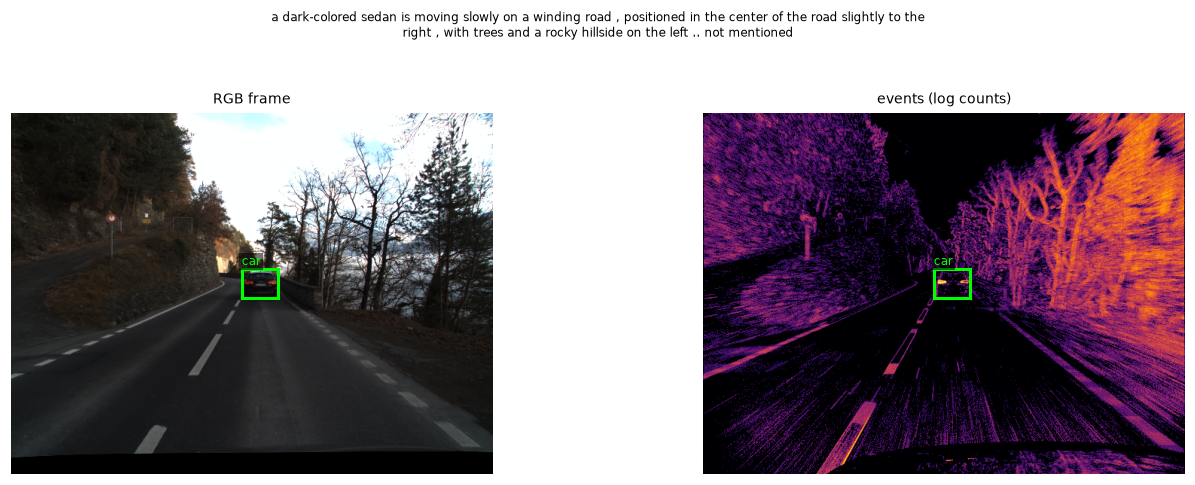

In [20]:
import os

if not os.path.exists(tgt["image_path"]):
    print(f"RGB frame not on disk, skipping:\n  {tgt['image_path']}")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    axes[0].imshow(denorm_image(inp["image"]))
    axes[0].set_title("RGB frame", fontsize=9)
    axes[1].imshow(np.log1p(acc), cmap="inferno")
    axes[1].set_title("events (log counts)", fontsize=9)
    for ax in axes:
        draw_box(ax, box, label=tgt["category"]); ax.axis("off")
    fig.suptitle(wrap(tgt["caption"], 110), fontsize=8, y=1.04)
    plt.tight_layout(); plt.show()

## 5. Browse a gallery

Several samples at once, to get a feel for the variety of object scales and scene
activity. Note how small most target boxes are relative to the frame.

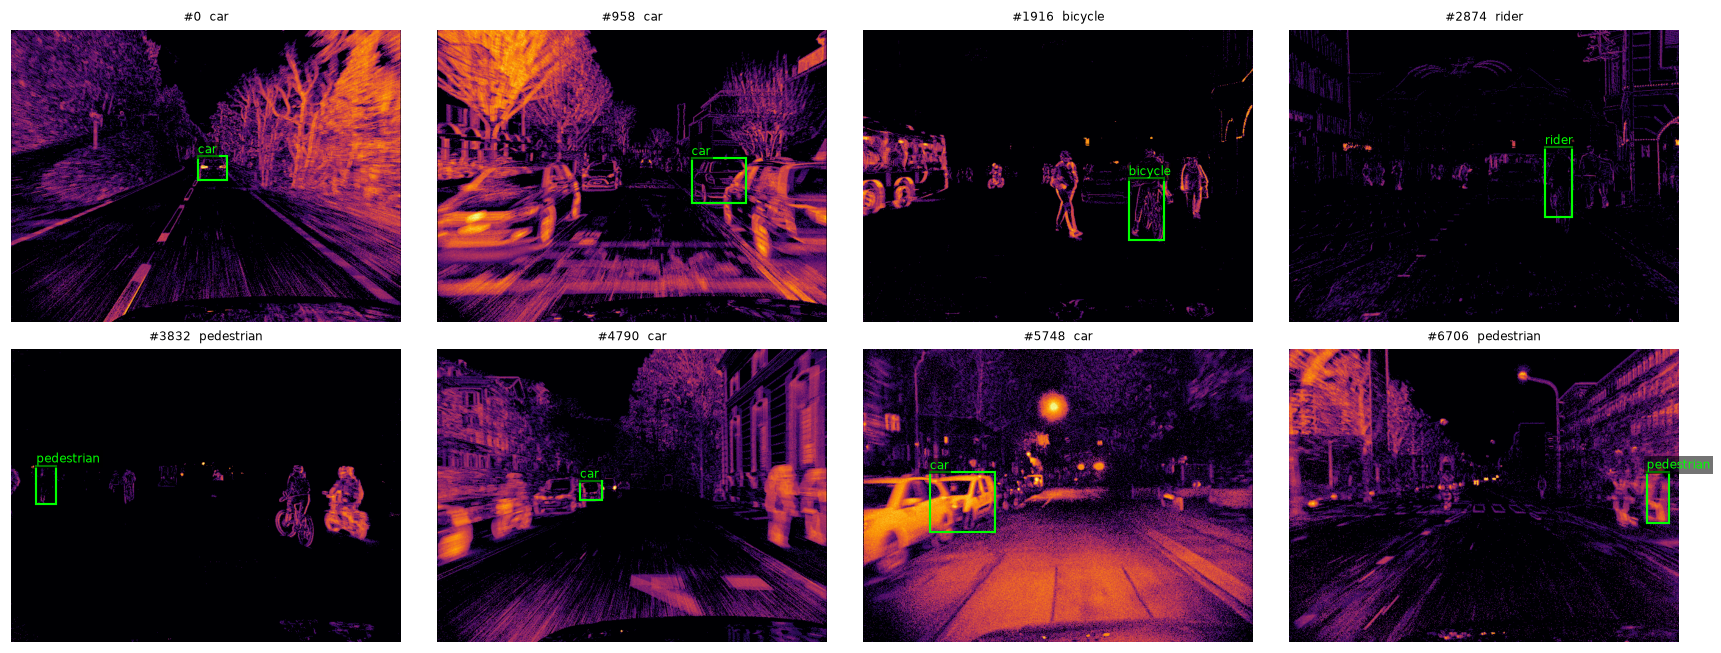

In [21]:
def show_gallery(indices, cols=4):
    rows = int(np.ceil(len(indices) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.0 * cols, 3.0 * rows))
    for ax, idx in zip(np.atleast_1d(axes).ravel(), indices):
        i, t = ds[idx]
        ax.imshow(np.log1p(i["event"].sum(0).numpy()), cmap="inferno")
        draw_box(ax, t["boxes"][0], color="lime", lw=1.4, label=t["category"])
        ax.set_title(f"#{idx}  {t['category']}", fontsize=8)
        ax.axis("off")
    for ax in np.atleast_1d(axes).ravel()[len(indices):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()


step = max(1, len(ds) // 8)
show_gallery(list(range(0, len(ds), step))[:8])

In [22]:
# one object, its three differently-worded captions (consecutive indices)
base = SAMPLE_IDX - (SAMPLE_IDX % 3)
for k in range(3):
    _, t = ds[base + k]
    print(f"[{base + k}] {t['category']:>10}  box={[round(float(v), 4) for v in t['boxes'][0]]}")
    print(f"{wrap(t['caption'], 96)}\n")

[0]        car  box=[0.5156, 0.4719, 0.075, 0.0812]
a dark-colored sedan is moving slowly on a winding road , positioned in the center of the road
slightly to the right , with trees and a rocky hillside on the left .. not mentioned

[1]        car  box=[0.5156, 0.4719, 0.075, 0.0812]
a sedan in a dark hue is seen traveling slowly on a curving road , positioned a bit to the right
of the middle , flanked by trees and a rugged hillside .. not mentioned

[2]        car  box=[0.5156, 0.4719, 0.075, 0.0812]
on a gently curving road , a dark sedan moves forward at a slow speed , keeping slightly right
of center , with trees and a steep rocky slope to the left .. not mentioned



## 6. Object scale — why this benchmark is hard

The metric is accuracy at IoU ≥ 0.95. Measuring the box-size distribution shows how much
spatial precision that actually demands.

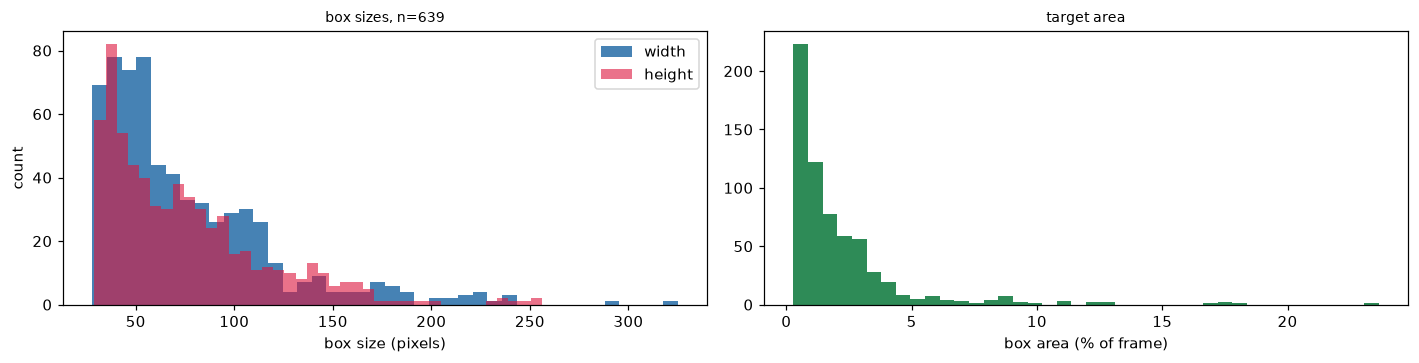

median box: 62 x 66 px  (1.29% of the frame)
IoU >= 0.95 on that box allows only a 1.59 px centre error
IoU >= 0.90 allows 3.26 px


In [23]:
N = 600
idxs = range(0, len(ds), max(1, len(ds) // N))
wh = np.array([[float(ds[i][1]["boxes"][0][2]), float(ds[i][1]["boxes"][0][3])] for i in idxs])
w_px, h_px = wh[:, 0] * W, wh[:, 1] * H

fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
axes[0].hist(w_px, bins=40, color="steelblue", label="width")
axes[0].hist(h_px, bins=40, color="crimson", alpha=0.6, label="height")
axes[0].set_xlabel("box size (pixels)"); axes[0].set_ylabel("count")
axes[0].set_title(f"box sizes, n={len(wh)}", fontsize=9); axes[0].legend()

area_pct = 100 * wh[:, 0] * wh[:, 1]
axes[1].hist(area_pct, bins=40, color="seagreen")
axes[1].set_xlabel("box area (% of frame)"); axes[1].set_title("target area", fontsize=9)
plt.tight_layout(); plt.show()

mw, mh = np.median(w_px), np.median(h_px)
print(f"median box: {mw:.0f} x {mh:.0f} px  ({np.median(area_pct):.2f}% of the frame)")
# identical boxes offset by d have IoU (w-d)/(w+d); solve for IoU = 0.95
print(f"IoU >= 0.95 on that box allows only a {mw * 0.05 / 1.95:.2f} px centre error")
print(f"IoU >= 0.90 allows {mw * 0.10 / 1.90:.2f} px")